In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib
from matplotlib.collections import LineCollection

matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
# plt.style.use('dark_background')

import pickle, gzip
import torch
from torch_geometric.data import Data
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import MessagePassing
from torch_geometric.utils import scatter

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

from scipy.spatial import cKDTree
import copy

ALGO COMO

Does the full graph geometry of void-like randoms contain information about the underlying matter density beyond simple local geometric summary statistics?

Busco describir el campo donde NO tengo tracers, donde NO hay halos -> los vacios

Inicialmente, que tanta informacion puedo sacar del campo void-like usando solo los halos

desde fisher se que los randoms agregan informacion diferente de alguna forma

## 1. Halos sin ASTRA

In [2]:
with gzip.open('graph_fid_0.pkl.gz', 'rb') as f:
    G = pickle.load(f)

In [3]:
halo_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'halo']
Nh = len(halo_nodes)
Nh

309740

In [4]:
old_to_new = {old_id: new_id for new_id, old_id in enumerate(halo_nodes)}

In [5]:
pos_halo = np.array([G.nodes[n]['pos'] for n in halo_nodes], dtype=np.float32)

pos = torch.tensor(pos_halo, dtype=torch.float32)
pos.shape

torch.Size([309740, 3])

In [6]:
x = torch.ones((Nh, 1), dtype=torch.float32)

In [7]:
src = []
dst = []
dist = []

for u, v, attr in G.edges(data=True):

    if attr['edge_type'] != 'HH':
        continue
    src.append(old_to_new[u])
    dst.append(old_to_new[v])
    dist.append(attr['distance'])

In [8]:
src = np.asarray(src, dtype=np.int64)
dst = np.asarray(dst, dtype=np.int64)
dist = np.asarray(dist, dtype=np.float32)
len(src)

1532295

In [9]:
edge_index = torch.tensor(np.vstack([np.concatenate([src, dst]),
                                     np.concatenate([dst, src])]), dtype=torch.long)

In [10]:
edge_distance = np.concatenate([dist, dist])
edge_attr = torch.tensor(edge_distance[:, None], dtype=torch.float32)
edge_index.shape,edge_attr.shape

(torch.Size([2, 3064590]), torch.Size([3064590, 1]))

In [11]:
data_halo = Data(x=x, pos=pos, edge_index=edge_index, edge_attr=edge_attr)
data_halo

Data(x=[309740, 1], edge_index=[2, 3064590], edge_attr=[3064590, 1], pos=[309740, 3])

In [12]:
random_nodes = [n for n, attr in G.nodes(data=True) if attr['node_type'] == 'random']
pos_rand = np.array([G.nodes[n]['pos'] for n in random_nodes], dtype=np.float32)

In [13]:
with open('delta_dm_randoms_R10.pkl', 'rb') as f:
    delta_dm_rand = pickle.load(f)

In [14]:
query_pos = torch.tensor(pos_rand, dtype=torch.float32)
query_y = torch.tensor(delta_dm_rand, dtype=torch.float32)

In [15]:
data_halo.size(), query_pos.size(), query_y.size()

((309740, 309740), torch.Size([130670, 3]), torch.Size([130670]))

In [16]:
Lbox = 1000.0
r_query = 30.0

In [17]:
halo_pos_np = data_halo.pos.numpy()
query_pos_np = query_pos.numpy()

In [18]:
assert len(query_pos) == len(query_y)
assert len(query_pos) == len(random_nodes)

In [19]:
tree_halo = cKDTree(halo_pos_np, boxsize=Lbox)
neighbors = tree_halo.query_ball_point(query_pos_np, r=r_query)

In [20]:
n_neighbors = np.array([len(n) for n in neighbors])

print('mean   :', n_neighbors.mean())
print('median :', np.median(n_neighbors))
print('16-84% :', np.percentile(n_neighbors, [16, 84]))
print('min/max:', n_neighbors.min(), n_neighbors.max())

mean   : 25.504140200505088
median : 24.0
16-84% : [14. 37.]
min/max: 0 103


In [21]:
query_idx = []
halo_idx = []
qh_dist = []

for q, neigh in enumerate(neighbors):

    if len(neigh) == 0:
        continue

    neigh = np.asarray(neigh, dtype=np.int64)

    delta = (halo_pos_np[neigh] - query_pos_np[q])
    delta -= Lbox * np.round(delta / Lbox)
    d = np.linalg.norm(delta, axis=1)
    query_idx.extend([q] * len(neigh))

    halo_idx.extend(neigh)
    qh_dist.extend(d)

In [22]:
query_idx = np.asarray(query_idx, dtype=np.int64)
halo_idx = np.asarray(halo_idx, dtype=np.int64)
qh_dist = np.asarray(qh_dist, dtype=np.float32)

query_idx.shape, halo_idx.shape, qh_dist.shape

((3332626,), (3332626,), (3332626,))

In [23]:
query_idx = torch.from_numpy(query_idx)
halo_idx = torch.from_numpy(halo_idx)
qh_dist = torch.from_numpy(qh_dist)

In [24]:
zero = n_neighbors == 0
zero.sum(), zero.mean()

(np.int64(11), np.float64(8.418152598148006e-05))

In [25]:
class DistanceConv(MessagePassing):

    def __init__(self, in_channels, out_channels):
        super().__init__(aggr='mean')

        self.message_mlp = nn.Sequential(nn.Linear(in_channels + 1, out_channels),
                                         nn.ReLU(),
                                         nn.Linear(out_channels, out_channels))

        self.update_mlp = nn.Sequential(nn.Linear(in_channels + out_channels, out_channels),
                                        nn.ReLU(),
                                        nn.Linear(out_channels, out_channels))

    def forward(self, x, edge_index, edge_dist):
        return self.propagate(edge_index, x=x, edge_dist=edge_dist)

    def message(self, x_j, edge_dist):
        m = torch.cat([x_j, edge_dist], dim=1)
        return self.message_mlp(m)

    def update(self, aggr_out, x):
        h = torch.cat([x, aggr_out], dim=1)
        return self.update_mlp(h)

In [26]:
class HaloEncoder(nn.Module):

    def __init__(self, hidden=32):
        super().__init__()

        self.conv1 = DistanceConv(1, hidden)
        self.conv2 = DistanceConv(hidden, hidden)

    def forward(self, data):

        x = data.x
        d = data.edge_attr / 30.0

        x = self.conv1(x, data.edge_index, d)
        x = F.relu(x)
        x = self.conv2(x, data.edge_index, d)
        return x

In [27]:
class QueryAggregator(nn.Module):

    def __init__(self, hidden=32):
        super().__init__()

        self.message_mlp = nn.Sequential(nn.Linear(hidden + 1, hidden),
                                         nn.ReLU(),
                                         nn.Linear(hidden, hidden),
                                         nn.ReLU())

        self.predictor = nn.Sequential(nn.Linear(hidden + 1, hidden),
                                       nn.ReLU(),
                                       nn.Linear(hidden, hidden // 2),
                                       nn.ReLU(),
                                       nn.Linear(hidden // 2, 1))

    def forward(self, halo_embed, halo_idx, query_idx, qh_dist, n_queries):
        h = halo_embed[halo_idx]
        d = (qh_dist / 30.0).unsqueeze(1)

        m = self.message_mlp(torch.cat([h, d], dim=1))
        q_embed = scatter(m, query_idx, dim=0, dim_size=n_queries, reduce='mean')

        counts = scatter(torch.ones_like(query_idx, dtype=torch.float32),
                         query_idx, dim=0, dim_size=n_queries, reduce='sum')

        counts = torch.log1p(counts).unsqueeze(1)

        q_embed = torch.cat([q_embed, counts], dim=1)
        pred = self.predictor(q_embed)

        return pred.squeeze(1)

In [28]:
class HaloToDM(nn.Module):

    def __init__(self, hidden=32):
        super().__init__()

        self.encoder = HaloEncoder(hidden=hidden)
        self.query = QueryAggregator(hidden=hidden)

    def forward(self, data_halo, halo_idx, query_idx, qh_dist, n_queries):
        halo_embed = self.encoder(data_halo)
        pred = self.query(halo_embed, halo_idx, query_idx, qh_dist, n_queries)
        return pred

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [30]:
xq = query_pos[:, 0].numpy()

In [31]:
train_mask = ((xq < 440.0) | (xq >= 860.0))
val_mask = ((xq >= 500.0) & (xq < 600.0))
test_mask = ((xq >= 700.0) & (xq < 800.0))

In [32]:
train_idx = torch.tensor(np.where(train_mask)[0], dtype=torch.long)
val_idx = torch.tensor(np.where(val_mask)[0], dtype=torch.long)
test_idx = torch.tensor(np.where(test_mask)[0], dtype=torch.long)

print('Train:', len(train_idx),
      'Val:', len(val_idx),
      'Test:', len(test_idx))

Train: 75380 Val: 13443 Test: 13426


In [33]:
y_mean = query_y[train_idx].mean()
y_std = query_y[train_idx].std()

query_y_norm = (query_y - y_mean) / y_std

print('mean train norm:', query_y_norm[train_idx].mean().item())
print('std train norm:', query_y_norm[train_idx].std().item())

mean train norm: -6.416869524628055e-08
std train norm: 1.0


In [34]:
data_halo = data_halo.to(device)

In [35]:
query_pos = query_pos.to(device)
query_y = query_y.to(device)
query_y_norm = query_y_norm.to(device)

In [36]:
halo_idx = halo_idx.to(device)
query_idx = query_idx.to(device)
qh_dist = qh_dist.to(device)

In [37]:
train_idx = train_idx.to(device)
val_idx = val_idx.to(device)
test_idx = test_idx.to(device)

In [38]:
y_mean = y_mean.to(device)
y_std = y_std.to(device)

In [39]:
Nq = len(query_y)

In [40]:
print(device)
print(data_halo)
print(query_y.shape)

cuda
Data(x=[309740, 1], edge_index=[2, 3064590], edge_attr=[3064590, 1], pos=[309740, 3])
torch.Size([130670])


In [41]:
torch.manual_seed(42)

model = HaloToDM(hidden=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3,weight_decay=1e-5)

In [42]:
history = {'train_loss': [],
           'val_loss': [],
           'train_r2': [],
           'val_r2': []}

In [43]:
best_val = np.inf
best_state = None

for epoch in range(501):
    # TRAIN
    model.train()
    optimizer.zero_grad()

    pred_norm = model(data_halo, halo_idx, query_idx, qh_dist, Nq)
    train_loss = F.mse_loss(pred_norm[train_idx], query_y_norm[train_idx])

    train_loss.backward()
    optimizer.step()

    # VALIDATION
    model.eval()

    with torch.no_grad():

        pred_norm = model(data_halo, halo_idx, query_idx, qh_dist, Nq)

        val_loss = F.mse_loss(pred_norm[val_idx], query_y_norm[val_idx])

        # volver a delta_DM
        pred_dm = (pred_norm * y_std + y_mean)

        train_true = (query_y[train_idx].cpu().numpy())
        train_pred = (pred_dm[train_idx].cpu().numpy())

        val_true = (query_y[val_idx].cpu().numpy())
        val_pred = (pred_dm[val_idx].cpu().numpy())

        train_r2 = r2_score(train_true, train_pred)
        val_r2 = r2_score(val_true, val_pred)

    history['train_loss'].append(train_loss.item())
    history['val_loss'].append(val_loss.item())
    history['train_r2'].append(train_r2)
    history['val_r2'].append(val_r2)

    if val_loss.item() < best_val:
        best_val = val_loss.item()
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 25 == 0:
        print(f'{epoch:3d} '
              f'train_loss={train_loss.item():.4f} '
              f'val_loss={val_loss.item():.4f} '
              f'R2_train={train_r2:.3f} '
              f'R2_val={val_r2:.3f}')

  0 train_loss=1.0307 val_loss=1.0436 R2_train=-0.029 R2_val=-0.042
 25 train_loss=1.0037 val_loss=1.0105 R2_train=-0.002 R2_val=-0.009
 50 train_loss=0.9678 val_loss=0.9665 R2_train=0.035 R2_val=0.035
 75 train_loss=0.7818 val_loss=0.7498 R2_train=0.234 R2_val=0.251
100 train_loss=0.6514 val_loss=0.6299 R2_train=0.350 R2_val=0.371
125 train_loss=0.5957 val_loss=0.5758 R2_train=0.406 R2_val=0.425
150 train_loss=0.5238 val_loss=0.5047 R2_train=0.480 R2_val=0.496
175 train_loss=0.4390 val_loss=0.4240 R2_train=0.563 R2_val=0.577
200 train_loss=0.3586 val_loss=0.3423 R2_train=0.646 R2_val=0.658
225 train_loss=0.3031 val_loss=0.2901 R2_train=0.697 R2_val=0.710
250 train_loss=0.2741 val_loss=0.2620 R2_train=0.726 R2_val=0.738
275 train_loss=0.2613 val_loss=0.2508 R2_train=0.740 R2_val=0.750
300 train_loss=0.2756 val_loss=0.2449 R2_train=0.744 R2_val=0.755
325 train_loss=0.2497 val_loss=0.2389 R2_train=0.751 R2_val=0.761
350 train_loss=0.2447 val_loss=0.2346 R2_train=0.756 R2_val=0.766
375 tr

In [44]:
model.load_state_dict(best_state)
model.eval()

HaloToDM(
  (encoder): HaloEncoder(
    (conv1): DistanceConv()
    (conv2): DistanceConv()
  )
  (query): QueryAggregator(
    (message_mlp): Sequential(
      (0): Linear(in_features=33, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): ReLU()
    )
    (predictor): Sequential(
      (0): Linear(in_features=33, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=1, bias=True)
    )
  )
)

In [45]:
model.eval()

HaloToDM(
  (encoder): HaloEncoder(
    (conv1): DistanceConv()
    (conv2): DistanceConv()
  )
  (query): QueryAggregator(
    (message_mlp): Sequential(
      (0): Linear(in_features=33, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): ReLU()
    )
    (predictor): Sequential(
      (0): Linear(in_features=33, out_features=32, bias=True)
      (1): ReLU()
      (2): Linear(in_features=32, out_features=16, bias=True)
      (3): ReLU()
      (4): Linear(in_features=16, out_features=1, bias=True)
    )
  )
)

In [46]:
with torch.no_grad():
    pred_norm = model(data_halo, halo_idx, query_idx, qh_dist, Nq)
    pred_dm = (pred_norm * y_std + y_mean)

In [47]:
true_test = (query_y[test_idx].cpu().numpy())
pred_test = (pred_dm[test_idx].cpu().numpy())

In [48]:
rmse_gnn = np.sqrt(mean_squared_error(true_test, pred_test))
r2_gnn = r2_score(true_test, pred_test)
r_gnn, _ = pearsonr(true_test,pred_test)

print('GNN RMSE :', rmse_gnn)
print('GNN R2   :', r2_gnn)
print('GNN r    :', r_gnn)

GNN RMSE : 0.08229935633770069
GNN R2   : 0.7626043558120728
GNN r    : 0.873496


In [49]:
print('TRUE:', true_test.mean(), true_test.std())
print('PRED:', pred_test.mean(), pred_test.std())

TRUE: -0.1988248 0.16891183
PRED: -0.20186412 0.14615841


| Model  | RMSE   | R²     | r      |
|--------|--------|--------|--------|
| Linear | 0.1553 | 0.1673 | 0.4090 |
| RF     | 0.1572 | 0.1465 | 0.3889 |
| GNN    | 0.1110 | 0.5765 | 0.7610 |

-------------------

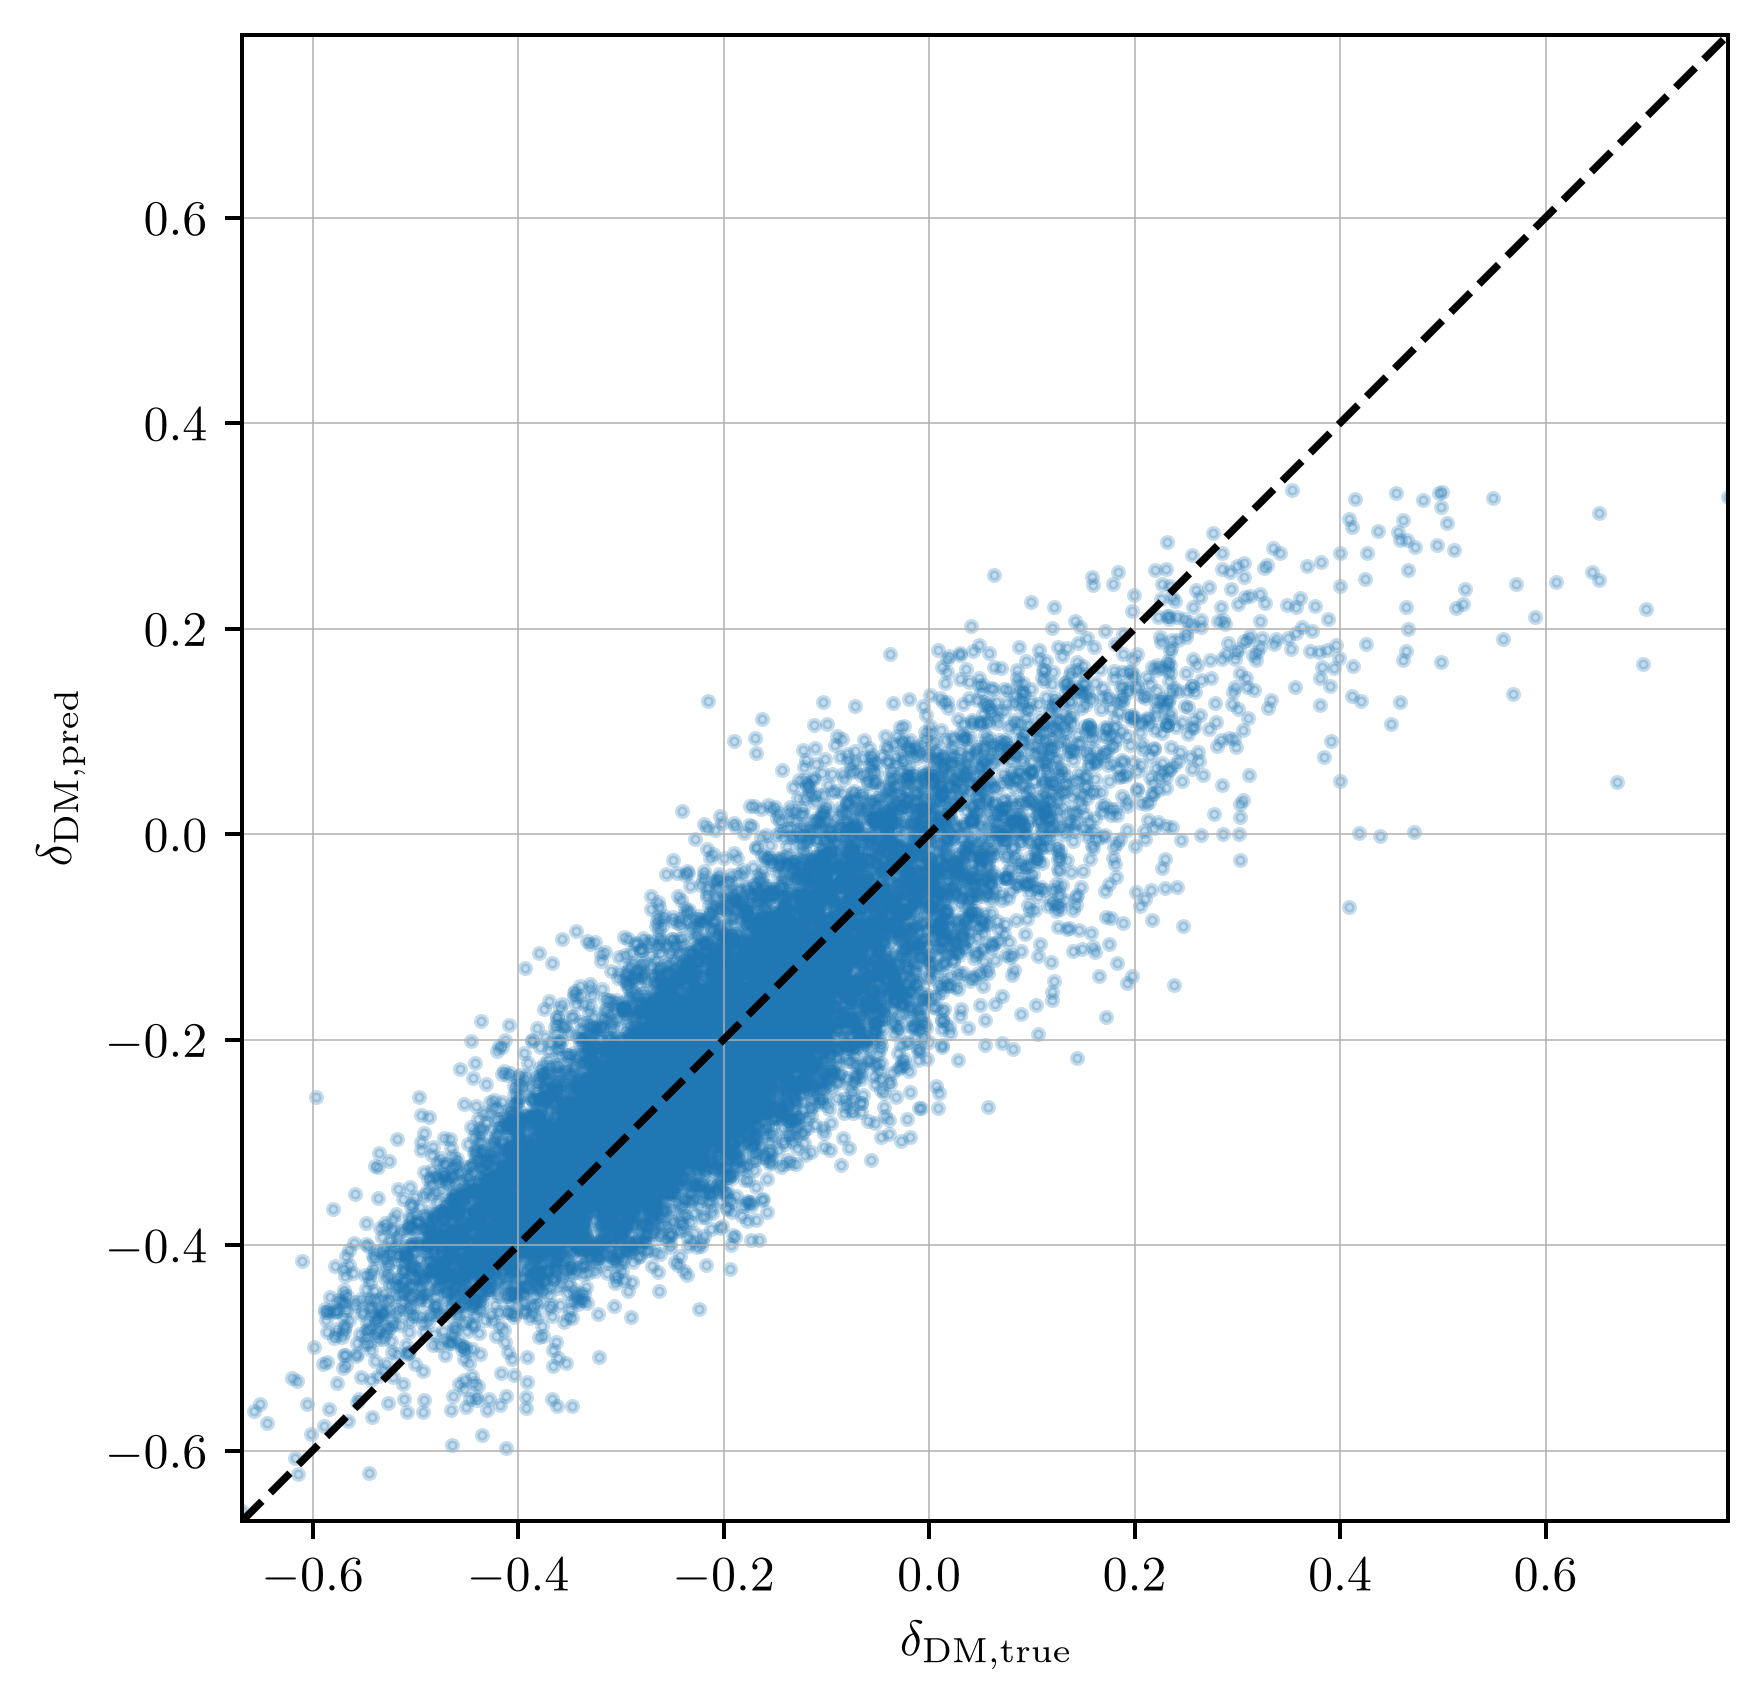

In [52]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.grid(lw=0.3)

ax.scatter(true_test, pred_test, s=4, alpha=0.25)

lo = min(true_test.min(), pred_test.min())
hi = max(true_test.max(), pred_test.max())

ax.plot([lo, hi], [lo, hi], '--', color='black', lw=1.5)

ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_xlabel(r'$\delta_{\rm DM,true}$')
ax.set_ylabel(r'$\delta_{\rm DM,pred}$')

plt.tight_layout()
ax.set_aspect('equal')
plt.show()

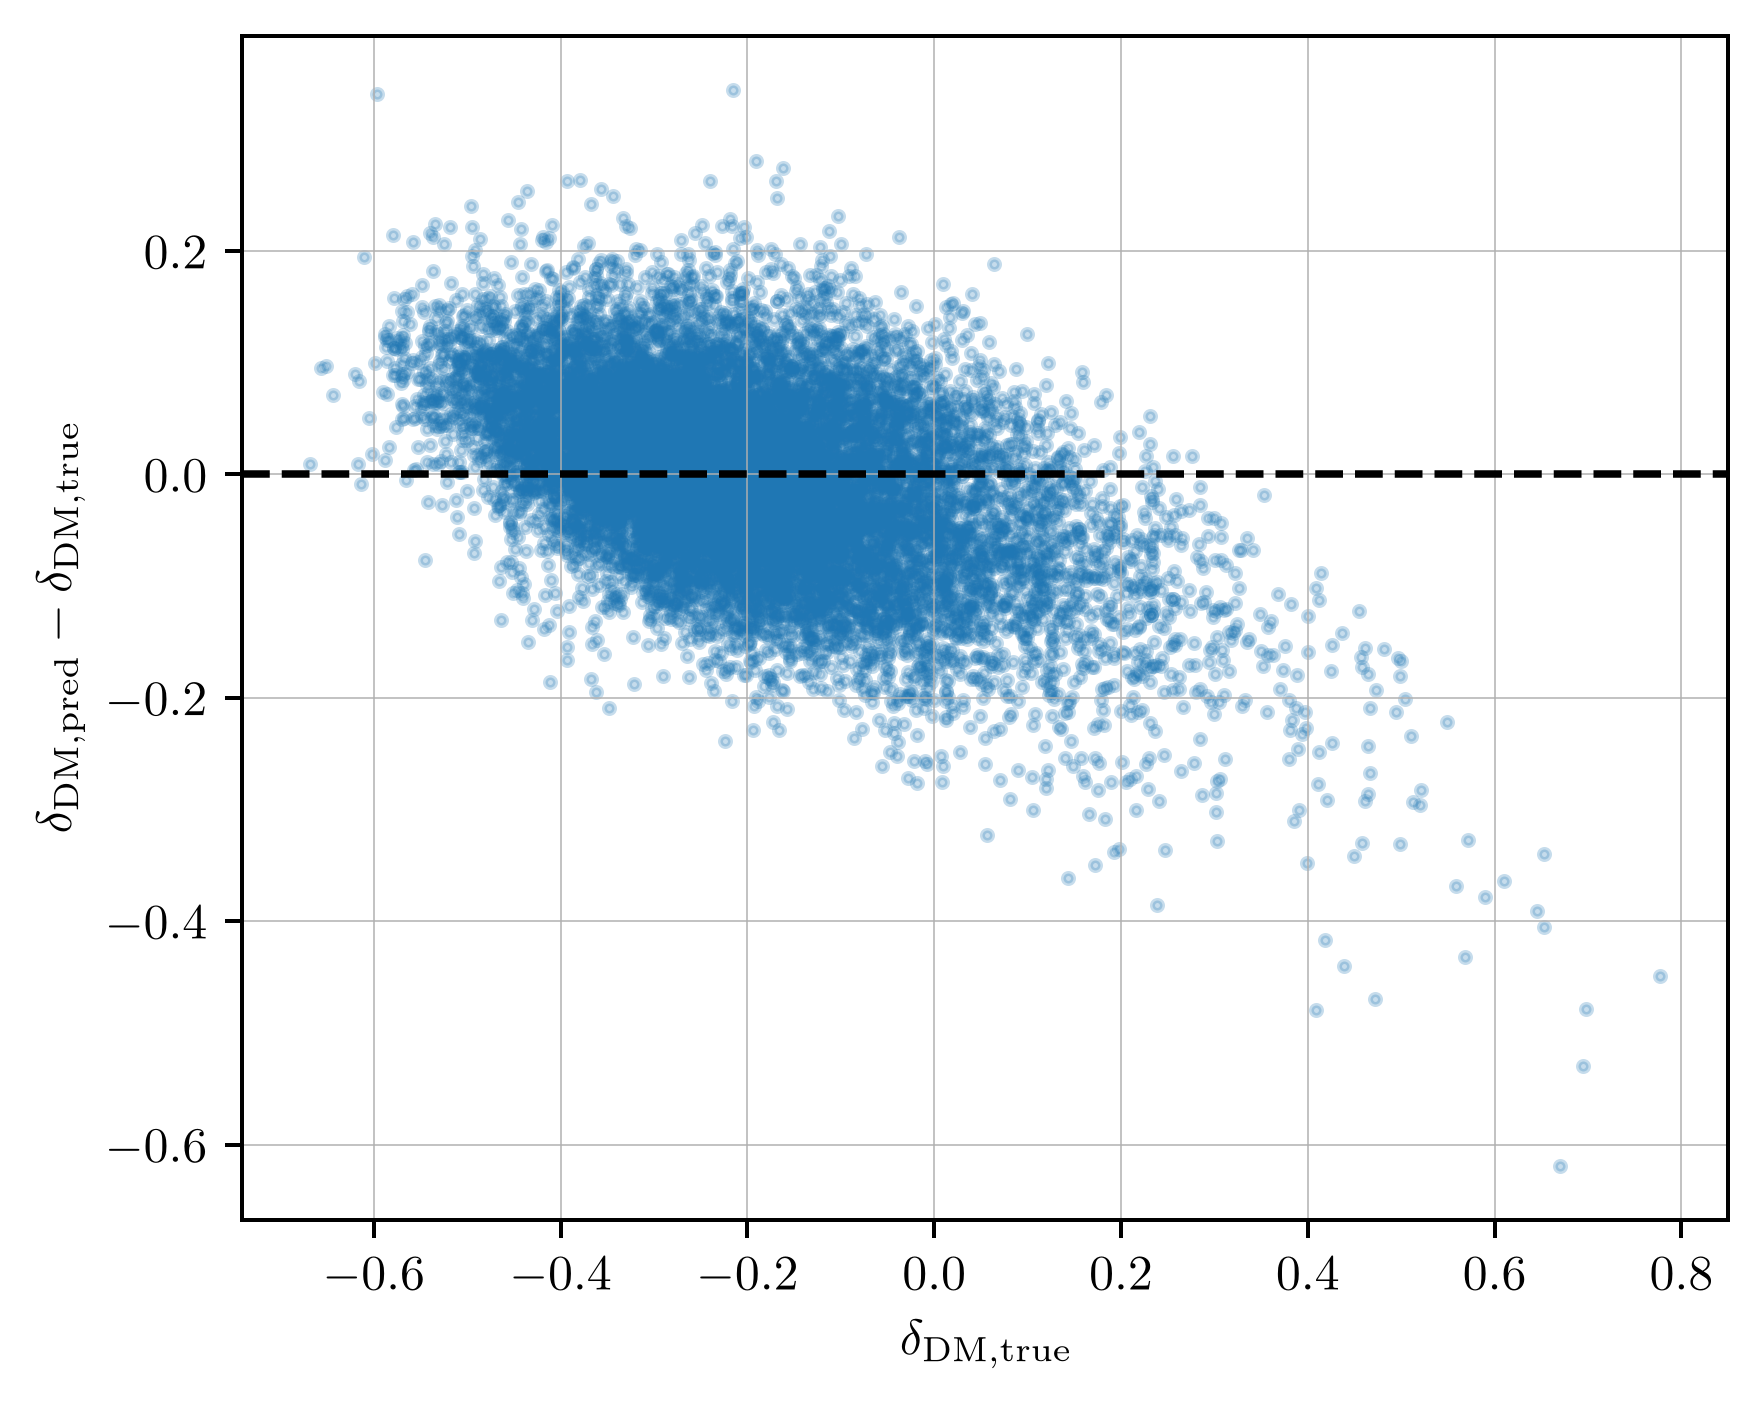

In [56]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.grid(lw=0.3)

ax.scatter(true_test, pred_test-true_test, s=4, alpha=0.25)
ax.axhline(0, ls='--', color='black', lw=1.5)

ax.set_xlabel(r'$\delta_{\rm DM,true}$')
ax.set_ylabel(r'$\delta_{\rm DM,pred}-\delta_{\rm DM,true}$')

plt.tight_layout()
plt.show()